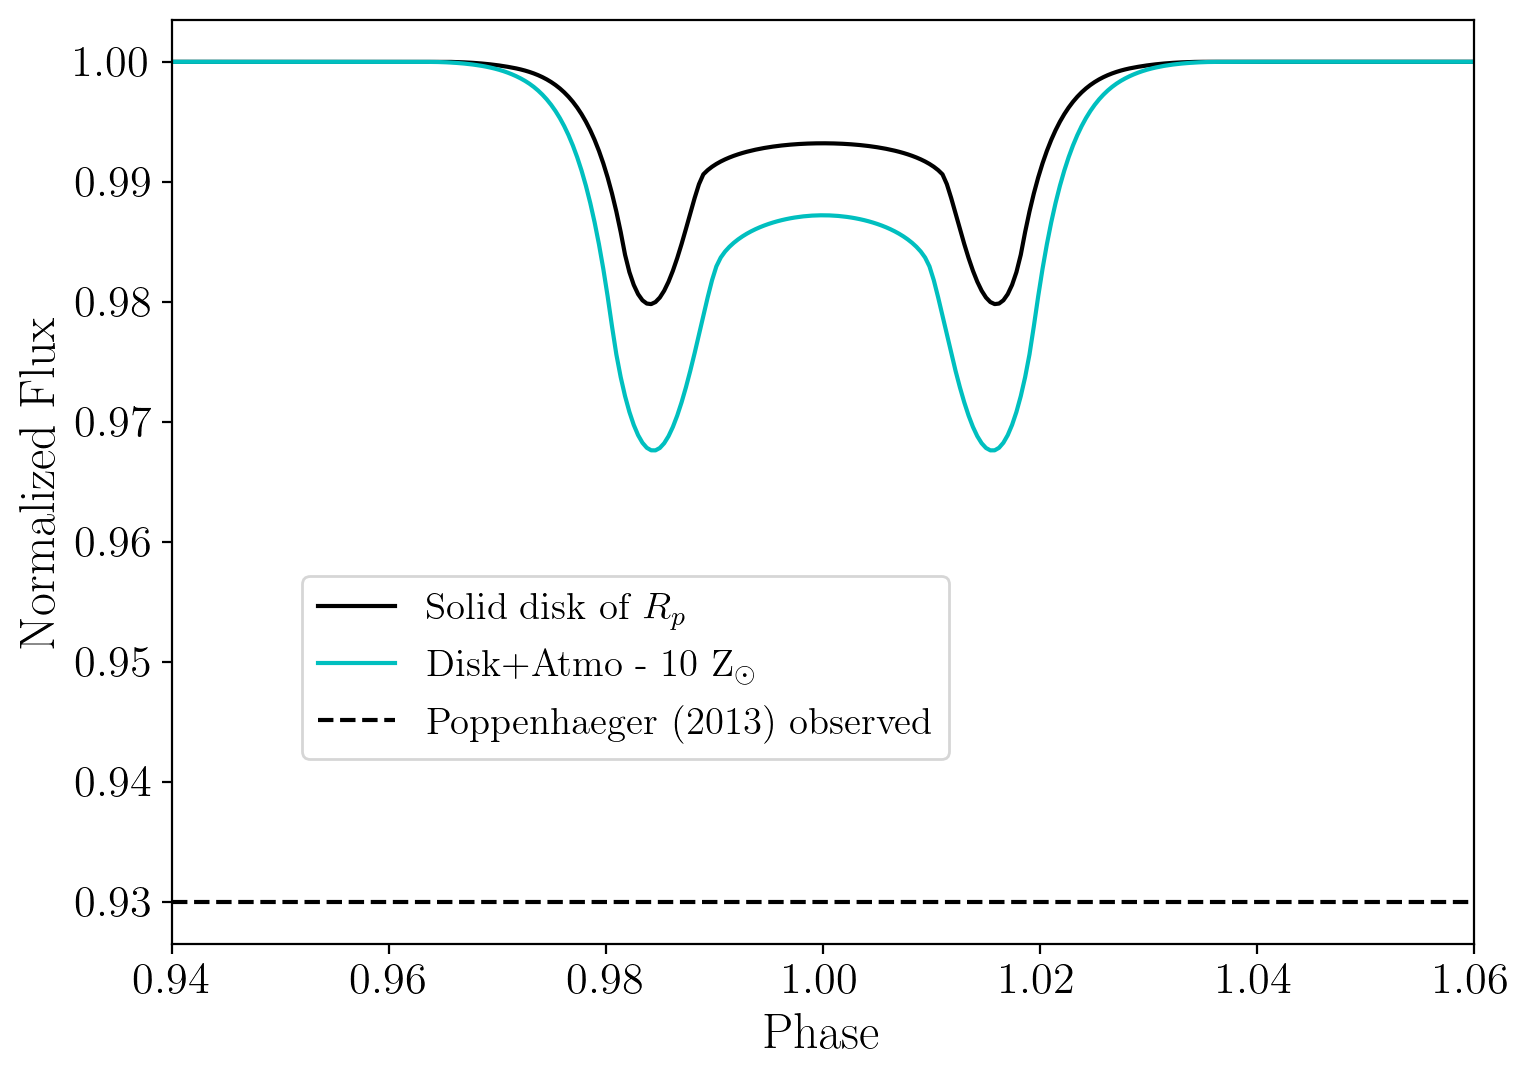

In [8]:
import xt_fns as xf
import numpy as np
import matplotlib.pyplot as plt
import batman

#Stellar parameters
Rs = 0.805 #radius (Rsun)
# Rs =  	0.7827 #radius (Rsun)
Ms = 0.846 #mass (Msun)
T = 0.34 #kT of corona in keV

#planetary parameters
Rp = 8135789600.0*5.6 #planet radius in cm 
RpRs = Rp/(Rs*6.957e10) #Rmax/Rs
aRs = 8.2830 #a/Rs
inc = 85.580 #inclination
t0 = 1 #phase of transit centre

#get emission scale height in stellar radii
He = xf.HfromT(T, Rs, Ms)
#get emission scale height in batman coordinates
he = xf.hfromH(He)
Nscale = 6
#photosphere edge in batman coords
Rx = xf.calcRx(he, Nscale)
intVals = xf.get_intVals(he, Nscale)

#set up the object to store the transit parameters
params = batman.TransitParams()
params.t0 = t0               #time of inferior conjunction
params.per = 1               #orbital period - set to 1 to keep within phase definitions
params.rp = RpRs * Rx        #planet radius (in units of stellar radii)
params.a = aRs * Rx          #semi-major axis (in units of stellar radii)
params.inc = inc             #orbital inclination (in degrees)
params.ecc = 0.              #eccentricity
params.w = 90.               #longitude of periastron (in degrees)
params.limb_dark = "custom"  #limb darkening model
params.u = [0]*6             #limb darkening coefficients
params.u[0] = intVals

#initialise a batman model at the calcuation phase times
#Setting up times for model
phaSt, phaFi = 0.9, 1.1 #phases to model
numBins = 500 #500 #number of bins to calculate the light curve at
binPhases = np.linspace(phaSt, phaFi, numBins) #bin centres

#set up batman model
mod = batman.TransitModel(params, binPhases, fac=5e-4)
#get the fluxes
flux1 = mod.light_curve(params)

pltparams = {"text.color" : "k",
          "xtick.color" : "k",
          "ytick.color" : "k"}
plt.rcParams.update(pltparams)


#plot the model
fig1 = plt.figure(figsize=(8.4,6.0))
# plt.plot(binPhases, old_flux,c='k') #Plot model
old_bin, old_flux = np.load('og_transit_hd189.npy').T
plt.plot(old_bin, old_flux,c='k',ls='-',label=r'Solid disk of $R_p$') #Plot model
# old_bin, old_flux = np.load('transit_hd189_10Z.npy').T
# plt.plot(old_bin, old_flux,c='b',ls='--',label=r'10 Z$_\odot$') #Plot model
# old_bin, old_flux = np.load('og_transit_hd189_Rmax.npy').T
# plt.plot(old_bin, old_flux,c='b',ls='--',label='Original') #Plot model
plt.plot(binPhases, flux1,c='c',label=r'Disk+Atmo - 10 Z$_\odot$') #Plot model
plt.axhline(0.93,c='k',ls='--',label='Poppenhaeger (2013) observed')
plt.xlabel('Phase',fontsize=18)
plt.ylabel('Normalized Flux',fontsize=18)
plt.tick_params(labelsize=16)
plt.xlim(0.94,1.06)
plt.legend(fontsize=14,loc=[0.1,0.2])

#plt.savefig('optR_HeBourrier.pdf', dpi=300)

Next try tau[11] = 100 for the whole array in tau.h

Then tau[11] = 1e-2

Then tau[11] = 1e-4

In [14]:
np.save('transit_hd189_10Z.npy',np.column_stack((binPhases,flux1)))

In [ ]:
# x, d, R, r_n, arg, trasnmission = np.genfromtxt('test_new',unpack=True,delimiter=',')
# ir, r_n, trasnmission = np.genfromtxt('transmissions.txt',unpack=True,delimiter=',')
# x, d, R, arg1, arg2, arg3 = np.genfromtxt('x_test',unpack=True,delimiter=',')

In [6]:
with open('transmissions.txt', 'r') as f:
    for i, line in enumerate(f, 1):
    # for line in range(20):
        # Skip empty lines
        if not line.strip():
            continue
        parts = line.strip().split(',')
        print(parts)
        if i>100:
            break

['0', '0.000000', '1.000000']
['1', '0.000804', '1.000000']
['2', '0.001608', '1.000000']
['3', '0.002412', '1.000000']
['4', '0.003216', '1.000000']
['5', '0.004020', '1.000000']
['6', '0.004824', '1.000000']
['7', '0.005628', '1.000000']
['8', '0.006432', '1.000000']
['9', '0.007236', '1.000000']
['10', '0.008040', '1.000000']
['11', '0.008844', '1.000000']
['12', '0.009649', '1.000000']
['13', '0.010453', '1.000000']
['14', '0.011257', '1.000000']
['15', '0.012061', '1.000000']
['16', '0.012865', '1.000000']
['17', '0.013669', '1.000000']
['18', '0.014473', '1.000000']
['19', '0.015277', '1.000000']
['20', '0.016081', '1.000000']
['21', '0.016885', '1.000000']
['22', '0.017689', '1.000000']
['23', '0.018493', '1.000000']
['24', '0.019297', '1.000000']
['25', '0.020101', '1.000000']
['26', '0.020905', '1.000000']
['27', '0.021709', '1.000000']
['28', '0.022513', '1.000000']
['29', '0.023317', '1.000000']
['30', '0.024121', '1.000000']
['31', '0.024925', '1.000000']
['32', '0.025729',

In [ ]:
for i in range(len(x)):
    if (x[i]+d[i]) < R[i]:
        print(i)
        

In [5]:
lawofcos = (d**2 + r_n**2 - x**2)/(2.*d*r_n)

print(d[0], r_n[0], x[0],  lawofcos[0], np.arccos(lawofcos[0]))

0.00109 0.004433 0.0876 -791.9047935935031 nan


/var/folders/1b/b30tn34j4p104kcg6lt_mnf00000gn/T/ipykernel_35007/928444693.py:3: RuntimeWarning: invalid value encountered in arccos
  print(d[0], r_n[0], x[0],  lawofcos[0], np.arccos(lawofcos[0]))


In [6]:
print(trasnmission[10000])

0.012121


0.095897
0.033609


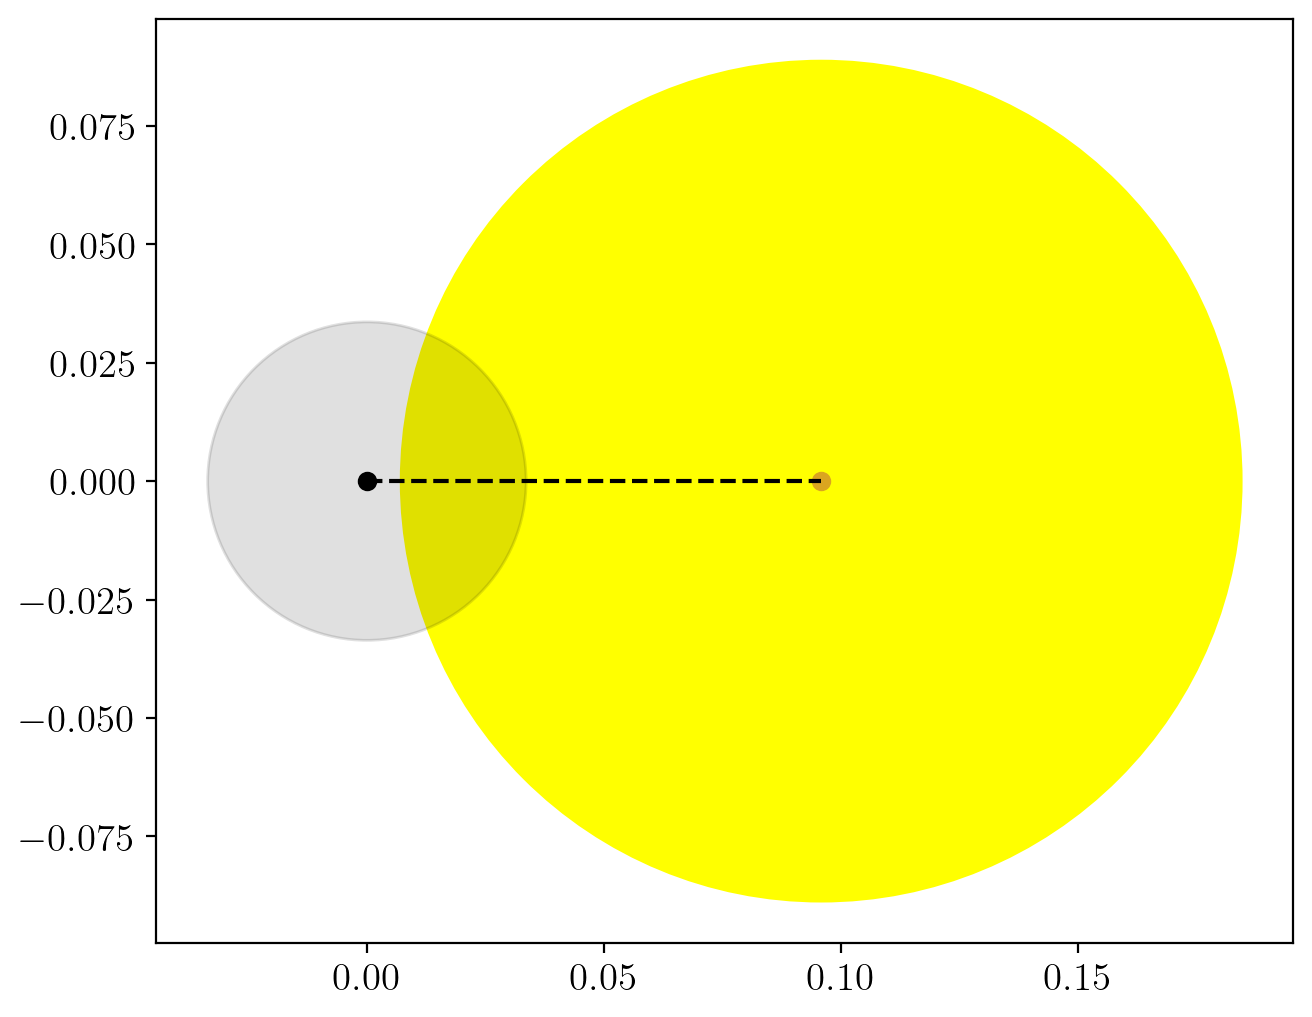

In [15]:
import matplotlib.patches as mpatches
fig2 = plt.figure(figsize=(8.4,6.0))
i = 9999
print(d[i])
print(r_n[i])
planet = mpatches.Circle((0,0),r_n[i], color='k', label='planet',alpha=trasnmission[i]*10)
star = mpatches.Circle((d[i],0),R[i], color='yellow', label='star')
plt.scatter(0,0,c='k')
plt.plot([0,d[i]],[0,0],c='k',ls='--')
plt.gca().add_patch(star)
plt.gca().add_patch(planet)
plt.scatter(d[i],0,c='goldenrod')

# plt.xlim(-r_n[i],d[i]+R[i]/8)
# plt.ylim(-R[i]/4,R[i]/4)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [12]:
np.arccos(lawofcos)

/var/folders/1b/b30tn34j4p104kcg6lt_mnf00000gn/T/ipykernel_9302/526751090.py:1: RuntimeWarning: invalid value encountered in arccos
  np.arccos(lawofcos)


array([nan, nan, nan, ..., nan, nan, nan])

In [ ]:
print(flux1)

In [ ]:
old_flux = flux1.copy()